# shape change visualization from token to embedding to lstm to output

we trace a batch of data through the entire `JointSemanticModel` and visualize exactly how the multi-dimensional tensor shape transforms at every single layer.

In [2]:
%matplotlib inline
import sys
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.model import JointSemanticModel

print("Loaded")

Loaded


### dummy data
batchsize=4
seqlength=10

In [3]:
vocab_size = 500
batch_size = 4
seq_len = 10
embed_dim = 64
hidden_dim = 128

model = JointSemanticModel(vocab_size=vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, snr_db=10.0)

#dummy input token
source_tokens = torch.randint(1, vocab_size, (batch_size, seq_len))
print(f"intital shape: {list(source_tokens.shape)} -> [Batch Size, Sequence Length]")

intital shape: [4, 10] -> [Batch Size, Sequence Length]


### embedding layer
2d to dense 3d vector.

In [4]:
with torch.no_grad():
    embedded_tokens = model.encoder.embedding(source_tokens)

print(f"Output Shape after embedding layer: {list(embedded_tokens.shape)} -> [Batch Size, Sequence Length, Embedding Dimension]")

Output Shape after embedding layer: [4, 10, 64] -> [Batch Size, Sequence Length, Embedding Dimension]


###The LSTM bottleneck (Destroying the Sequence)
This is the most critical transformation , The LSTM reads the 10 words, but we ONLY extract the final hidden memory state. The Sequence dimension (`10`) is completely gone

In [6]:
with torch.no_grad():
    _, (hidden_state, cell_state) = model.encoder.lstm(embedded_tokens)

print(f"Bottleneck Hidden State Shape: {list(hidden_state.shape)} -> [Num Layers, Batch Size, Hidden Dimension]")


Bottleneck Hidden State Shape: [1, 4, 128] -> [Num Layers, Batch Size, Hidden Dimension]


### The AWGN Channel 
Physical radio noise corrupts the *values* inside the tensor, but it does not change the shape

In [7]:
with torch.no_grad():
    noisy_hidden = model.channel(hidden_state)

print(f"Noisy Payload Shape: {list(noisy_hidden.shape)} -> [Num Layers, Batch Size, Hidden Dimension]")

Noisy Payload Shape: [1, 4, 128] -> [Num Layers, Batch Size, Hidden Dimension]


###The Decoder (Reconstruction)
The Decoder takes the Noisy vector and expands it back out, predicting probabilities across the entire vocabulary for every single step of the sequence

In [8]:
with torch.no_grad():
    final_logits = model(source_tokens, source_tokens)

print(f"Final Output Logits Shape: {list(final_logits.shape)} -> [Batch Size, Sequence Length, Vocabulary Size]")

Final Output Logits Shape: [4, 10, 500] -> [Batch Size, Sequence Length, Vocabulary Size]


### visualization
Here is a physical map of how the tensor morphs as it travels through the network.

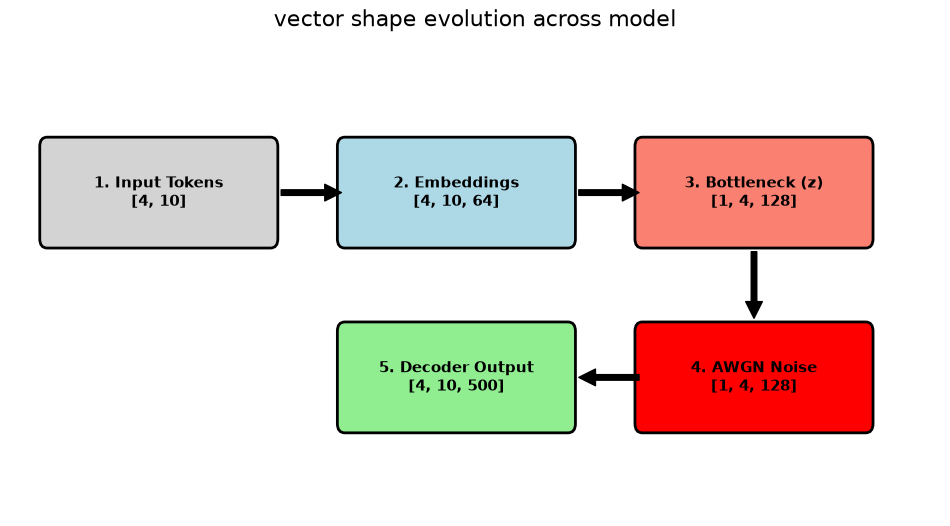

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

def draw_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.1", fc=color, ec="black", lw=2)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=11, fontweight='bold')


draw_box(ax, 0, 4, 3, 1, f"1. Input Tokens\n[4, 10]", "lightgray")
draw_box(ax, 4, 4, 3, 1, f"2. Embeddings\n[4, 10, {embed_dim}]", "lightblue")
draw_box(ax, 8, 4, 3, 1, f"3. Bottleneck (z)\n[1, 4, {hidden_dim}]", "salmon")
draw_box(ax, 8, 2, 3, 1, f"4. AWGN Noise\n[1, 4, {hidden_dim}]", "red")
draw_box(ax, 4, 2, 3, 1, f"5. Decoder Output\n[4, 10, {vocab_size}]", "lightgreen")


ax.annotate('', xy=(4, 4.5), xytext=(3.1, 4.5), arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('', xy=(8, 4.5), xytext=(7.1, 4.5), arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('', xy=(9.5, 3.1), xytext=(9.5, 3.9), arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('', xy=(7.1, 2.5), xytext=(8, 2.5), arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("vector shape evolution across model", fontsize=16, pad=20)
plt.xlim(-0.5, 12)
plt.ylim(1, 6)
plt.show()